# Weeds vs Ornamentals — Multi-Dimensional Word Embedding Comparison

This notebook uses a WEAT test to compare plants commonly referred to as 'weeds', to plants which are commonly reffered to as 'garden flowers' referred throughout this project as 'ornamentals'. These two word sets are copared against 5 attribute poles: 
1. __Edible__ - Whether the words lean towards edible or inedible wordlists.
2. __Aliveness__ - A combination of sentience and animacy as the word lists shared 12 words creating a large overlap. Whether the words lean towards animate, sentient, or inanimate, insentient wordlists.
3. __Valence__ - Whether the words lean towards plesent or unplesent wordlists.
4. __Morality__ - In this instance to understand whether the words lean towards virtue or evil wordlists
5. __Value__ - Whether the words lean towards worth or worthless wordlists.

## Process 
This code book begins with Step 0 where key imports are made and then follows an 8 Step process. 

- Step 1: Configuration — target sets, comparisons, and settings
- Step 2: Cross-axis vocabulary overlap check
- Step 3: Core functions — embeddings, cosine similarity, and lean scores
- Step 4: Statistical validation — effect size, permutation test, sensitivity check
- Step 5: Load embeddings once, then run every comparison
- Step 6: Multiple-comparison correction (Benjamini–Hochberg FDR)
- Step 7: Summary table
- Step 8: Radar charts


Each step currently returns outputs to enable easier testing of the code and process, however the code book also includes a final section 'Main — rerun everything end-to-end' which enables the results to be viewed together reruning every step in the sequence in one go, rather than clicking through box by box.


## Step 0: Imports

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Step 1: Configuration — target sets, comparisons, and settings

In [32]:
GLOVE_PATH = "glove.6B.200d.txt"  #names the file path so it can be used later in the codebook

# If the GloVe file isn't found locally, download and extract it automatically.
# This means the file never needs to be committed to GitHub -- anyone who clones
# the repo and runs this cell will fetch it fresh (~822MB zip, one-time download).
import os, zipfile, urllib.request

if not os.path.exists(GLOVE_PATH):
    zip_path = "glove.6B.zip"
    url = "https://nlp.stanford.edu/data/glove.6B.zip"
    print(f"{GLOVE_PATH} not found locally -- downloading from {url} ...")
    print("(this is an ~822MB download and may take a few minutes)")
    urllib.request.urlretrieve(url, zip_path)
    print("Download complete. Extracting...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extract(GLOVE_PATH)
    os.remove(zip_path)
    print("Done -- GloVe file ready.")
else:
    print(f"{GLOVE_PATH} found locally, skipping download.")

# TARGET SET 1 — Creates a list of weed words.
TARGET_SET_1 = [
    "chickweed", "bindweed", "nettles", "clover", "groundsel",
    "dandelion", "cleavers", "buttercup", "yarrow", "thistle",
    "ragwort", "daisy", "storksbill", "speedwell",
    "fireweed", "celandine", "bittercress",
]

# TARGET SET 2 — Creates a list of ornamental words.
TARGET_SET_2 = [
     "bluebell", "chrysanthemum", "clematis", "cosmos",
    "daffodil", "dahlia", "echinacea", "geranium", "honeysuckle", "hydrangea", "iris", "lavender",
    "lily", "marigold", "peony", "rose", "sunflower", "rhododendron",
    "tansy", "tulip", 
]

N_PERMUTATIONS = 10000   # number of random shuffles for the significance test
RANDOM_SEED = 42         # fixed seed so results are reproducible run-to-run
FDR_ALPHA = 0.05         # significance threshold used by the multiple-comparison correction in Step 6

In [33]:
# EDIBLE - Creates a list of edible and inedible words
EDIBLE_A = [
    "eating", "eatable", "food", "provisions", "bread", "eats", "meal",
    "foodstuffs", "comestible", "consumable", "nonpoisonous", "digestible",
    "tasty", "nourishing", "nutritious", "nutritive", "palatable", "savory", "esculent",
]
EDIBLE_B = [
    "nonedible", "uneatable", "indigestible", "undigestible", "nondigestible",
    "nonnutritious", "inedible", "noxious", "toxic", "poisonous", "bitter",
    "nauseating", "rancid", "rotten", "sour", "unsavory", "yucky",
]

# LIVENESS - Creates a list of animate, sentient, and inanimate, insentient words
ALIVENESS_A = [
    "alive", "live", "existing", "existent", "quick", "breathing", "animate",
    "fleshly", "bodily", "embodied", "alert", "animated", "awake", "brisk",
    "dynamic", "lively", "vigorous", "active", "thriving", "vivacious",
    "aware", "conscious", "cognizant", "mindful", "regardful", "observant",
    "attentive", "perceptive", "receptive", "knowing", "noticing", "observing",
    "perceiving", "recognizing", "seeing", "understanding",
]
ALIVENESS_B = [
    "lifeless", "mineral", "mechanical", "unconscious", "insensate", "unfeeling",
    "insentient", "senseless", "insensible", "comatose", "exanimate", "dead",
    "dull", "idle", "inactive", "inert", "inoperative", "motionless", "soulless",
    "spiritless", "inanimate",
]

# VALENCE - Creates a list of plesent and unplestent words 
VALENCE_A = [
    "caress", "freedom", "health", "love", "peace", "cheer", "friend", "heaven",
    "loyal", "pleasure", "diamond", "gentle", "honest", "lucky", "rainbow",
    "diploma", "gift", "honor", "miracle", "sunrise", "family", "happy",
    "laughter", "paradise", "vacation",
]
VALENCE_B = [
    "abuse", "crash", "filth", "murder", "sickness", "accident", "death", "grief", "assault", "disaster", "hatred", "pollute", "tragedy",
    "divorce", "jail", "poverty", "ugly", "cancer", "kill",
    "agony", "prison",
]

# MORALITY - Creates a list of virtuous and evil words
MORALITY_A = [
    "honorable", "ethical", "moral", "noble", "decent", "righteous",
    "worthy", "upright", "principled", "commendable", "creditable", "blameless",
    "irreproachable", "incorruptible", "guiltless", "reputable", "esteemed",
    "scrupulous", "angelic", "upstanding", "incorrupt", "praiseworthy", "faithful",
]
MORALITY_B = [
    "bad", "wicked", "immoral", "sinful", "unprincipled", "sinister", "malevolent",
    "malicious", "malignant", "villainous", "vicious", "nefarious", "wrong",
    "evilness", "badness", "sin", "sinfulness", "villainy", "immorality",
    "wickedness", "satanism", "diabolism", "corruption", "devilishness",
    "devilry", "fiendishness", "maleficent",
]

# VALUE - Creates a list of worth and worthless words. 
VALUE_A = [
    "treasure", "appreciate", "enjoy", "respect", "prize", "cherish",
    "admire", "worth", "price", "cost", "merit", "importance", "significance",
    "admiration", "prestige", "greatness", "excellence", "use", "usefulness",
    "benefit", "help", "profit", "service", "utility",
]
VALUE_B = [
    "useless", "meaningless", "purposeless", "worthless", "unsubstantial",
    "aimless", "insignificant", "inconsequential", "unimportant", "trivial",
    "empty", "cheap", "inadequate", "inferior", "unsatisfactory", "substandard", "deficient",
]

In [34]:
# COMPARISONS - Configures dictionaries for each comparison
COMPARISONS = [
    {"name": "Edible",     "pole_a": "edible",   "pole_b": "inedible",   "words_a": EDIBLE_A,     "words_b": EDIBLE_B},
    {"name": "Aliveness",  "pole_a": "alive",    "pole_b": "not alive",  "words_a": ALIVENESS_A,  "words_b": ALIVENESS_B},
    {"name": "Valence",    "pole_a": "pleasant", "pole_b": "unpleasant", "words_a": VALENCE_A,    "words_b": VALENCE_B},
    {"name": "Morality",   "pole_a": "virtuous", "pole_b": "evil",       "words_a": MORALITY_A,   "words_b": MORALITY_B},
    {"name": "Value",      "pole_a": "worth",    "pole_b": "worthless",  "words_a": VALUE_A,      "words_b": VALUE_B},
]

print(f"{len(COMPARISONS)} active comparisons configured: {[c['name'] for c in COMPARISONS]}")

5 active comparisons configured: ['Edible', 'Aliveness', 'Valence', 'Morality', 'Value']


## Step 2: Cross-axis vocabulary overlap check

This checks whether any two comparisons' word lists share vocabulary. 

NB - _following this test within a previous iteration Animacy and Sentience were collapsed into a single "Aliveness" attrebute._

In [35]:
def check_cross_axis_overlap(comparisons):
    """
    Compares every pair of comparisons' combined word lists (both poles)
    and prints any words they have in common.
    """
    print("=" * 60)
    print("STEP 2: Cross-Axis Vocabulary Overlap Check")
    print("=" * 60)

    any_overlap = False
    for i in range(len(comparisons)):
        for j in range(i + 1, len(comparisons)):
            c1, c2 = comparisons[i], comparisons[j]
            set1 = {w.lower() for w in c1["words_a"] + c1["words_b"]}
            set2 = {w.lower() for w in c2["words_a"] + c2["words_b"]}
            shared = set1 & set2
            if shared:
                any_overlap = True
                print(f"  '{c1['name']}' <-> '{c2['name']}': "
                      f"{len(shared)} shared word(s): {sorted(shared)}")
    if not any_overlap:
        print("  No shared vocabulary found between any pair of comparisons.")
    return any_overlap

In [36]:
check_cross_axis_overlap(COMPARISONS)

STEP 2: Cross-Axis Vocabulary Overlap Check
  No shared vocabulary found between any pair of comparisons.


False

## Step 3: Core functions — embeddings, cosine similarity, and lean scores
This section sets up the core functions required for the tests. 

In [37]:

def load_embeddings_with_rank(filepath, words_needed):
    """
    Loads GloVe vectors for relevant words, and records each word's FREQUENCY RANK
    """
    words_needed = {w.lower() for w in words_needed}
    embeddings = {}
    ranks = {}

    with open(filepath, "r", encoding="utf-8") as f:
        for rank, line in enumerate(f, start=1):
            word, _, rest = line.rstrip("\n").partition(" ")
            if word in words_needed:
                embeddings[word] = np.array(rest.split(" "), dtype=np.float32)
                ranks[word] = rank

    return embeddings, ranks

In [38]:
def vocab_check(label, words, embeddings, ranks, verbose=True):
    """
    prints a presence/frequency report for one word list returning only the words that are found within the GloVe vocabulary.
    """
    found, missing = [], []
    for w in words:
        key = w.lower()
        if key in embeddings:
            found.append(w)
        else:
            missing.append(w)

    if verbose:
        print(f"\n--- {label} ---")
        for w in found:
            print(f"  {w:<15} found   (frequency rank: {ranks[w.lower()]:,})")
        for w in missing:
            print(f"  {w:<15} MISSING - not in this GloVe vocabulary")
        if missing:
            print(f"  -> Dropping {len(missing)} missing word(s): {missing}")
        if found:
            avg_rank = np.mean([ranks[w.lower()] for w in found])
            print(f"  Average frequency rank for '{label}': {avg_rank:,.0f}  (lower = more common)")

    return found, missing

In [39]:
def cosine_similarity(vec_a, vec_b):
    """
    Calculates the standard cosine similarity between two vectors
    """
    return np.dot(vec_a, vec_b) / (np.linalg.norm(vec_a) * np.linalg.norm(vec_b))

def word_lean_score(word_vector, attr1_vectors, attr2_vectors):
    """
    Computes the mean cosine similarity fof a word to attribute pole A 
    minus it's mean cosine similarity to attribute pole B. 
    If it's positive it leans toward pole A 
    If it's negative it leans towards pole b. 
    """
    sim_to_attr1 = [cosine_similarity(word_vector, v) for v in attr1_vectors]
    sim_to_attr2 = [cosine_similarity(word_vector, v) for v in attr2_vectors]
    return float(np.mean(sim_to_attr1) - np.mean(sim_to_attr2))


def build_group_distribution(words, embeddings, attr1_vectors, attr2_vectors):
    """
    Calls the word_lean_score function to compute the lean score for every word in one target group.
    """
    scores = {}
    for w in words:
        vec = embeddings.get(w.lower())
        if vec is not None:
            scores[w] = word_lean_score(vec, attr1_vectors, attr2_vectors)
    return scores

def print_group_distribution(label, scores, pos_label="A", neg_label="B"):
    """
    Prints each word's individual lean score, sorted, plus group summary stats.
    """
    print(f"\n--- {label}: word lean scores ({pos_label} <-- 0 --> {neg_label}) ---")
    for w, s in sorted(scores.items(), key=lambda x: x[1], reverse=True):
        direction = f"{pos_label}-leaning" if s > 0 else f"{neg_label}-leaning"
        print(f"  {w:<15} {s:+.4f}  ({direction})")
    values = list(scores.values())
    print(f"  Group mean: {np.mean(values):+.4f}   Group std dev: {np.std(values, ddof=1):.4f}")

## Step 4: Statistical validation — effect size, permutation test, sensitivity check

This step sets up the functions to test the validity of the difference between weeds and ornamentals on each axis. 
- Effect size (Cohen's-d-style) standardises the gap between the two groups' mean lean scores, so results are comparable across comparisons regardless of scale.
- The permutation test checks significance without assuming normally distributed data or relying on group-size formulas — it repeatedly reshuffles group labels to build a null distribution, then sees how extreme the real difference is by comparison. Chosen due to the small, non-random wordlists.
- The sensitivity check (leave-one-out) tests whether results depend too heavily on any single word, guarding against one outlier word skewing the whole comparison. The sensitivity check is set to print the top 8 most influential words per comparison. 

In [40]:

def effect_size(scores_1, scores_2):
    """
    Standardised effect size (same convention as the original WEAT
    paper): the difference in group means divided by the standard
    deviation of the two groups combined.
    """
    combined = np.concatenate([scores_1, scores_2])
    return (np.mean(scores_1) - np.mean(scores_2)) / np.std(combined, ddof=1)


def run_permutation_test(scores_1, scores_2, n_permutations=N_PERMUTATIONS, seed=RANDOM_SEED):
    """
    Randomly reshuffles the weed/ornamental labels thousands of times to build
    a null distribution, then checks how extreme the real observed
    difference is relative to that null distribution.
    """
    rng = np.random.default_rng(seed)

    values_1 = np.array(list(scores_1.values()))
    values_2 = np.array(list(scores_2.values()))
    n1 = len(values_1)

    observed_diff = np.mean(values_1) - np.mean(values_2)
    pooled = np.concatenate([values_1, values_2])

    extreme_count = 0
    for _ in range(n_permutations):
        rng.shuffle(pooled)
        perm_diff = np.mean(pooled[:n1]) - np.mean(pooled[n1:])
        if abs(perm_diff) >= abs(observed_diff):
            extreme_count += 1

    p_value = extreme_count / n_permutations
    d = effect_size(values_1, values_2)
    return observed_diff, p_value, d

In [41]:
def sensitivity_check(scores_1, scores_2, label_1="Group 1", label_2="Group 2", top_n=8):
    """
    Leave-one-out check: removes one word at a time and recomputes the
    effect size, to see whether the result depends heavily on any single
    word. Only the top `top_n` most influential words are printed here to
    keep the output manageable across five comparisons -- the full,
    unabridged list is still returned.
    """
    baseline_values_1 = np.array(list(scores_1.values()))
    baseline_values_2 = np.array(list(scores_2.values()))
    baseline_diff = np.mean(baseline_values_1) - np.mean(baseline_values_2)
    baseline_effect = effect_size(baseline_values_1, baseline_values_2)

    print(f"\nFull-sample result -> difference: {baseline_diff:+.4f}, effect size: {baseline_effect:+.4f}")
    print(f"--- Leave-one-out (top {top_n} most influential words shown) ---")

    results = []
    for word in scores_1:
        reduced = {w: s for w, s in scores_1.items() if w != word}
        values_1 = np.array(list(reduced.values()))
        diff = np.mean(values_1) - np.mean(baseline_values_2)
        d = effect_size(values_1, baseline_values_2)
        results.append((word, label_1, diff, d, d - baseline_effect))

    for word in scores_2:
        reduced = {w: s for w, s in scores_2.items() if w != word}
        values_2 = np.array(list(reduced.values()))
        diff = np.mean(baseline_values_1) - np.mean(values_2)
        d = effect_size(baseline_values_1, values_2)
        results.append((word, label_2, diff, d, d - baseline_effect))

    results.sort(key=lambda r: abs(r[4]), reverse=True)
    for word, group, diff, d, shift in results[:top_n]:
        print(f"  Remove '{word}' ({group}): difference={diff:+.4f}, effect size={d:+.4f}, shift={shift:+.4f}")
    if len(results) > top_n:
        print(f"  ... {len(results) - top_n} more word(s) not shown (full list is returned by this function).")

    return results

## Step 5: Load embeddings once, then run every comparison

All words across all five comparisons plus both target sets are loaded from the GloVe file in a single pass. Then each comparison runs the full Step 1-4 pipeline in turn: vocab check, lean scores, permutation test, sensitivity check.

In [42]:
def gather_all_words(comparisons, t1, t2):
    words = set(t1) | set(t2)
    for c in comparisons:
        words |= set(c["words_a"]) | set(c["words_b"])
    return list(words)

all_words = gather_all_words(COMPARISONS, TARGET_SET_1, TARGET_SET_2)
embeddings, ranks = load_embeddings_with_rank(GLOVE_PATH, all_words)

t1, _ = vocab_check("Target Set 1 (weeds)", TARGET_SET_1, embeddings, ranks)
t2, _ = vocab_check("Target Set 2 (ornamentals)", TARGET_SET_2, embeddings, ranks)

if t1 and t2:
    r1 = np.mean([ranks[w.lower()] for w in t1])
    r2 = np.mean([ranks[w.lower()] for w in t2])
    print(f"\nFrequency comparison -- weeds avg rank: {r1:,.0f} | ornamentals avg rank: {r2:,.0f}")
    if abs(r1 - r2) > 100000:
        print("  NOTE: large frequency gap between groups -- worth keeping in mind when interpreting results.")


--- Target Set 1 (weeds) ---
  chickweed       found   (frequency rank: 199,781)
  bindweed        found   (frequency rank: 234,196)
  nettles         found   (frequency rank: 48,928)
  clover          found   (frequency rank: 31,341)
  groundsel       found   (frequency rank: 242,326)
  dandelion       found   (frequency rank: 58,209)
  cleavers        found   (frequency rank: 101,372)
  buttercup       found   (frequency rank: 76,249)
  yarrow          found   (frequency rank: 53,011)
  thistle         found   (frequency rank: 27,274)
  ragwort         found   (frequency rank: 185,600)
  daisy           found   (frequency rank: 17,176)
  speedwell       found   (frequency rank: 116,823)
  fireweed        found   (frequency rank: 200,932)
  celandine       found   (frequency rank: 263,939)
  storksbill      MISSING - not in this GloVe vocabulary
  bittercress     MISSING - not in this GloVe vocabulary
  -> Dropping 2 missing word(s): ['storksbill', 'bittercress']
  Average frequency 

In [43]:
def run_comparison(name, pole_a, pole_b, words_a, words_b, embeddings, ranks, t1, t2):
    """
    Runs the full Steps 1-4 pipeline for ONE comparison: vocab check for
    both attribute poles, lean scores for both target groups, a
    permutation test, and a sensitivity check. Returns everything in a
    dict so Steps 6-8 can summarise across all comparisons at once.
    """
    print("\n" + "=" * 60)
    print(f"COMPARISON: {name}  ({pole_a} vs {pole_b})")
    print("=" * 60)

    found_a, _ = vocab_check(f"{name}: {pole_a}", words_a, embeddings, ranks)
    found_b, _ = vocab_check(f"{name}: {pole_b}", words_b, embeddings, ranks)

    vec_a = [embeddings[w.lower()] for w in found_a]
    vec_b = [embeddings[w.lower()] for w in found_b]

    scores_1 = build_group_distribution(t1, embeddings, vec_a, vec_b)
    scores_2 = build_group_distribution(t2, embeddings, vec_a, vec_b)

    print_group_distribution(f"weeds -- {name}", scores_1, pos_label=pole_a, neg_label=pole_b)
    print_group_distribution(f"ornamentals -- {name}", scores_2, pos_label=pole_a, neg_label=pole_b)

    diff, p, d = run_permutation_test(scores_1, scores_2)
    print(f"\nPermutation test ({N_PERMUTATIONS:,} shuffles): "
          f"observed diff={diff:+.4f}, p={p:.4f}, effect size d={d:+.4f}")

    sensitivity_check(scores_1, scores_2, "weeds", "ornamentals")

    return {
        "name": name, "pole_a": pole_a, "pole_b": pole_b,
        "weed_mean": float(np.mean(list(scores_1.values()))),
        "ornamental_mean": float(np.mean(list(scores_2.values()))),
        "diff": diff, "p": p, "d": d,
        "scores_1": scores_1, "scores_2": scores_2,
    }

In [44]:
results = []
for c in COMPARISONS:
    r = run_comparison(embeddings=embeddings, ranks=ranks, t1=t1, t2=t2, **c)
    results.append(r)


COMPARISON: Edible  (edible vs inedible)

--- Edible: edible ---
  eating          found   (frequency rank: 4,526)
  food            found   (frequency rank: 566)
  provisions      found   (frequency rank: 4,935)
  bread           found   (frequency rank: 5,873)
  eats            found   (frequency rank: 16,789)
  meal            found   (frequency rank: 6,859)
  foodstuffs      found   (frequency rank: 25,524)
  consumable      found   (frequency rank: 102,209)
  nonpoisonous    found   (frequency rank: 383,763)
  digestible      found   (frequency rank: 86,089)
  tasty           found   (frequency rank: 25,110)
  nourishing      found   (frequency rank: 64,740)
  nutritious      found   (frequency rank: 35,667)
  nutritive       found   (frequency rank: 137,844)
  palatable       found   (frequency rank: 30,491)
  savory          found   (frequency rank: 34,019)
  eatable         MISSING - not in this GloVe vocabulary
  comestible      MISSING - not in this GloVe vocabulary
  escule

## Step 6: Multiple-comparison correction (Benjamini–Hochberg FDR)

Running five permutation tests instead of one means there's a higher chance one of them looks
"significant" purely by chance. This applies a Benjamini–Hochberg false-discovery-rate
correction across all five p-values and flags which ones still hold up afterwards.

In [45]:
def benjamini_hochberg(results, alpha=FDR_ALPHA):
    """
    Adjusts p-values across multiple tests so that, on average, no more
    than `alpha` proportion of the tests called "significant" are false
    positives. Adds 'p_adj' and 'significant_fdr' to each result dict.
    """
    m = len(results)
    order = sorted(range(m), key=lambda i: results[i]["p"])
    sorted_p = [results[i]["p"] for i in order]

    p_adj = [0.0] * m
    running_min = 1.0
    for rank in range(m, 0, -1):
        i = order[rank - 1]
        running_min = min(running_min, sorted_p[rank - 1] * m / rank)
        p_adj[i] = running_min

    for i, r in enumerate(results):
        r["p_adj"] = p_adj[i]
        r["significant_fdr"] = p_adj[i] < alpha

    return results

results = benjamini_hochberg(results)

print(f"Benjamini-Hochberg FDR correction applied (alpha = {FDR_ALPHA})\n")
for r in sorted(results, key=lambda r: r["p"]):
    flag = "SIGNIFICANT" if r["significant_fdr"] else "not significant"
    print(f"  {r['name']:<10} raw p={r['p']:.4f}   adjusted p={r['p_adj']:.4f}   -> {flag}")

Benjamini-Hochberg FDR correction applied (alpha = 0.05)

  Value      raw p=0.0149   adjusted p=0.0392   -> SIGNIFICANT
  Valence    raw p=0.0157   adjusted p=0.0392   -> SIGNIFICANT
  Aliveness  raw p=0.0249   adjusted p=0.0415   -> SIGNIFICANT
  Edible     raw p=0.1519   adjusted p=0.1899   -> not significant
  Morality   raw p=0.2491   adjusted p=0.2491   -> not significant


## Step 7: Summary table

One row per comparison, sorted by the size of the effect, so the strongest separators between weeds and ornamentals are at the top.

In [46]:
summary_df = pd.DataFrame([
    {
        "comparison": r["name"],
        "pole_a": r["pole_a"], "pole_b": r["pole_b"],
        "weed_mean": r["weed_mean"], "ornamental_mean": r["ornamental_mean"],
        "diff (weed-ornamental)": r["diff"],
        "effect size d": r["d"],
        "p (raw)": r["p"], "p (FDR-adjusted)": r["p_adj"],
        "significant (FDR)": r["significant_fdr"],
    }
    for r in results
]).sort_values("effect size d", key=abs, ascending=False).reset_index(drop=True)

summary_df

,comparison,pole_a,pole_b,weed_mean,ornamental_mean,diff (weed-ornamental),effect size d,p (raw),p (FDR-adjusted),significant (FDR)
0,Valence,pleasant,unpleasant,0.014943,0.045870,-0.030926,-0.795381,0.0157,0.039250,True
1,Value,worth,worthless,-0.050409,0.006119,-0.056528,-0.790415,0.0149,0.039250,True
2,Aliveness,alive,not alive,-0.060743,-0.027355,-0.033388,-0.747736,0.0249,0.041500,True
3,Edible,edible,inedible,-0.042507,-0.022096,-0.020412,-0.487553,0.1519,0.189875,False
4,Morality,virtuous,evil,-0.033083,-0.019713,-0.013370,-0.404020,0.2491,0.249100,False


## Step 8: Radar charts

Two different Radar charts are created to present these findings:

- **Separation radar** — one polygon, radius = |effect size d| per axis. Answers "which of
  these five factors most strongly separates weeds from ornamentals?"
- **Profile radar** — two overlaid polygons (weeds, ornamentals), each axis z-scored so the two
  groups sit on a comparable footing per-axis. Shows the qualitative "shape" of each group
  across all five dimensions at once — useful for a discussion section.

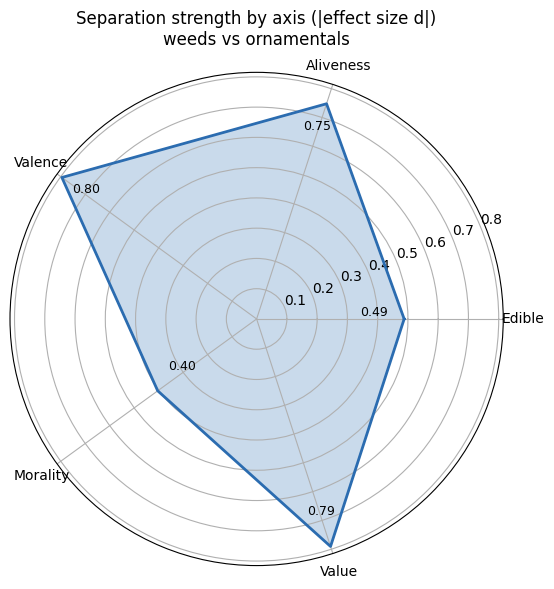

In [47]:
def radar_separation_chart(results):
    """One polygon: |effect size d| per comparison axis."""
    labels = [r["name"] for r in results]
    values = [abs(r["d"]) for r in results]
    n = len(labels)
    angles = [i / n * 2 * np.pi for i in range(n)]
    values_closed, angles_closed = values + values[:1], angles + angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.plot(angles_closed, values_closed, linewidth=2, color="#2b6cb0")
    ax.fill(angles_closed, values_closed, alpha=0.25, color="#2b6cb0")
    for angle, value in zip(angles, values):
        ax.text(angle, value - 0.10, f"{value:.2f}", ha="center", va="bottom", fontsize=9)
    ax.set_xticks(angles)
    ax.set_xticklabels(labels)
    ax.set_title("Separation strength by axis (|effect size d|)\nweeds vs ornamentals", pad=20)
    plt.tight_layout()
    plt.show()

radar_separation_chart(results)

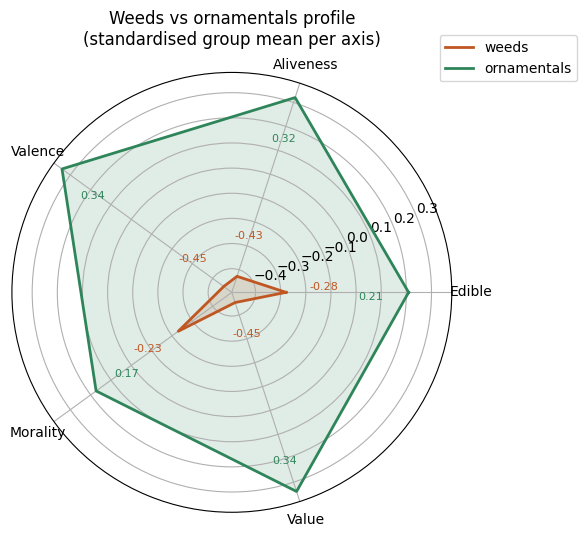

In [48]:
def radar_profile_chart(results):
    """Two overlaid polygons: standardised weed mean vs ornamental mean, per axis."""
    labels = [r["name"] for r in results]
    weed_z, ornamental_z = [], []
    for r in results:
        combined = np.concatenate([list(r["scores_1"].values()), list(r["scores_2"].values())])
        std = np.std(combined, ddof=1)
        mean = np.mean(combined)
        weed_z.append((r["weed_mean"] - mean) / std if std > 0 else 0.0)
        ornamental_z.append((r["ornamental_mean"] - mean) / std if std > 0 else 0.0)

    n = len(labels)
    angles = [i / n * 2 * np.pi for i in range(n)]
    weed_closed, ornamental_closed = weed_z + weed_z[:1], ornamental_z + ornamental_z[:1]
    angles_closed = angles + angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.plot(angles_closed, weed_closed, linewidth=2, color="#c05621", label="weeds")
    ax.fill(angles_closed, weed_closed, alpha=0.15, color="#c05621")
    ax.plot(angles_closed, ornamental_closed, linewidth=2, color="#2f855a", label="ornamentals")
    ax.fill(angles_closed, ornamental_closed, alpha=0.15, color="#2f855a")
    for angle, value in zip(angles, weed_z):
        ax.text(angle, value + 0.15, f"{value:.2f}", ha="center", va="bottom",
                 fontsize=8, color="#c05621")
    for angle, value in zip(angles, ornamental_z):
        ax.text(angle, value - 0.15, f"{value:.2f}", ha="center", va="top",
                 fontsize=8, color="#2f855a")
    ax.set_xticks(angles)
    ax.set_xticklabels(labels)
    ax.set_title("Weeds vs ornamentals profile\n(standardised group mean per axis)", pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()

radar_profile_chart(results)

## Main — rerun everything end-to-end

Reruns every step in sequence in one go, rather than clicking through box by box.

STEP 2: Cross-Axis Vocabulary Overlap Check
  No shared vocabulary found between any pair of comparisons.

--- Target Set 1 (weeds) ---
  chickweed       found   (frequency rank: 199,781)
  bindweed        found   (frequency rank: 234,196)
  nettles         found   (frequency rank: 48,928)
  clover          found   (frequency rank: 31,341)
  groundsel       found   (frequency rank: 242,326)
  dandelion       found   (frequency rank: 58,209)
  cleavers        found   (frequency rank: 101,372)
  buttercup       found   (frequency rank: 76,249)
  yarrow          found   (frequency rank: 53,011)
  thistle         found   (frequency rank: 27,274)
  ragwort         found   (frequency rank: 185,600)
  daisy           found   (frequency rank: 17,176)
  speedwell       found   (frequency rank: 116,823)
  fireweed        found   (frequency rank: 200,932)
  celandine       found   (frequency rank: 263,939)
  storksbill      MISSING - not in this GloVe vocabulary
  bittercress     MISSING - not in

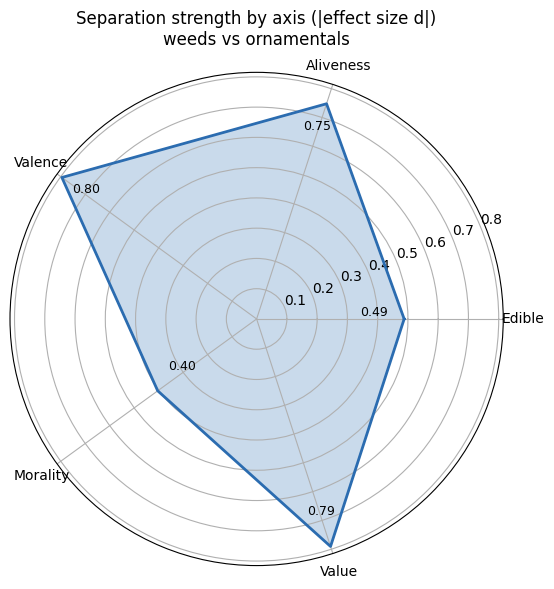

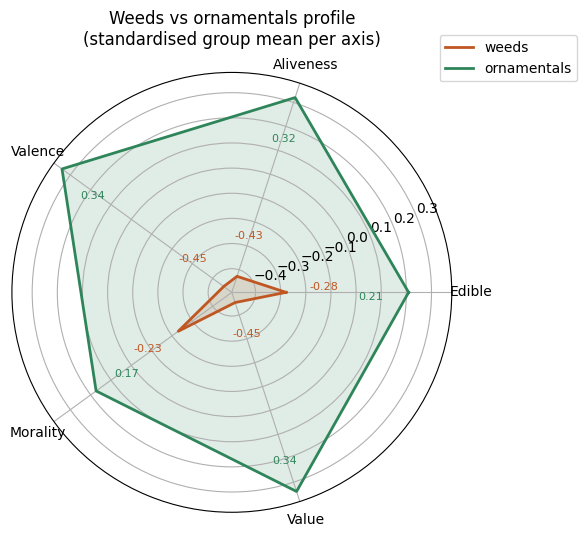

In [49]:
def main():
    all_words = gather_all_words(COMPARISONS, TARGET_SET_1, TARGET_SET_2)
    embeddings, ranks = load_embeddings_with_rank(GLOVE_PATH, all_words)

    check_cross_axis_overlap(COMPARISONS)
    t1, _ = vocab_check("Target Set 1 (weeds)", TARGET_SET_1, embeddings, ranks)
    t2, _ = vocab_check("Target Set 2 (ornamentals)", TARGET_SET_2, embeddings, ranks)

    results = [run_comparison(embeddings=embeddings, ranks=ranks, t1=t1, t2=t2, **c) for c in COMPARISONS]
    results = benjamini_hochberg(results)

    df = pd.DataFrame([
        {"comparison": r["name"], "effect size d": r["d"], "p (FDR-adjusted)": r["p_adj"]}
        for r in results
    ]).sort_values("effect size d", key=abs, ascending=False)
    print("\n\nSUMMARY")
    print(df.to_string(index=False))

    radar_separation_chart(results)
    radar_profile_chart(results)
    return results

if __name__ == "__main__":
    results = main()